# Mini project 2: Статистический анализ клиентов
Цель проекта — провести базовый статистический анализ клиентов: изучить общую сумму покупок, сегментировать клиентов, проверить выбросы, изучить корреляции и сравнить города.

## 1. Описание данных

`client_id` — идентификатор клиента

`client_name` — имя клиента

`town` — город

`orders_count` — количество заказов

`total_amount` — общая сумма покупок

`avg_order_amount` — средняя сумма заказа

In [353]:
import pandas as pd
import matplotlib.pyplot as plt

data = {
    "client_id": [1, 2, 3, 4, 5, 6, 7, 8],
    "client_name": ["Ivan", "Anna", "Oleg", "Maria", "Pavel", "Elena", "Sergey", "Daria"],
    "town": ["Moscow", "Kazan", "Moscow", "Moscow", "Kazan", "Samara", "Kazan", "Moscow"],
    "orders_count": [3, 2, 1, 4, 2, 1, 5, 1],
    "total_amount": [11500, 11000, 2000, 16000, 4000, 1500, 22000, 3000],
    "avg_order_amount": [3833, 5500, 2000, 4000, 2000, 1500, 4400, 3000]
}

df = pd.DataFrame(data)
df

,client_id,client_name,town,orders_count,total_amount,avg_order_amount
0,1,Ivan,Moscow,3,11500,3833
1,2,Anna,Kazan,2,11000,5500
2,3,Oleg,Moscow,1,2000,2000
3,4,Maria,Moscow,4,16000,4000
4,5,Pavel,Kazan,2,4000,2000
5,6,Elena,Samara,1,1500,1500
6,7,Sergey,Kazan,5,22000,4400
7,8,Daria,Moscow,1,3000,3000


## 2. Базовая статистика

In [354]:
total_amount_stats = {
  "mean":   df["total_amount"].mean(),
  "median": df["total_amount"].median(),
  "min":    df["total_amount"].min(),
  "max":    df["total_amount"].max(),
  "range":  df["total_amount"].max() - df["total_amount"].min(),
  "std":    df["total_amount"].std()
}
total_amount_stats

{'mean': np.float64(8875.0),
 'median': 7500.0,
 'min': 1500,
 'max': 22000,
 'range': 20500,
 'std': 7505.950020769237}

### Вывод:
Медиана по общей выручке ниже среднего значения. Скорее всего есть пара крупных заказов, которая тянет среднее значение вверх.

## 3. Квантили и сегментация

In [355]:
df.sort_values("total_amount", ascending=False)[
  ["client_name", "town", "orders_count", "total_amount", "avg_order_amount"]
]

,client_name,town,orders_count,total_amount,avg_order_amount
6,Sergey,Kazan,5,22000,4400
3,Maria,Moscow,4,16000,4000
0,Ivan,Moscow,3,11500,3833
1,Anna,Kazan,2,11000,5500
4,Pavel,Kazan,2,4000,2000
7,Daria,Moscow,1,3000,3000
2,Oleg,Moscow,1,2000,2000
5,Elena,Samara,1,1500,1500


### Квантили (25%, 50% (медиана), 75%)

In [356]:
quantiles = {
  "q25": df["total_amount"].quantile(0.25),
  "q50": df["total_amount"].quantile(0.5),
  "q75": df["total_amount"].quantile(0.75)
}
quantiles

{'q25': np.float64(2750.0),
 'q50': np.float64(7500.0),
 'q75': np.float64(12625.0)}

### Разделяем клиентов по сегментам основанным на выручке: `high_value`, `middle_value`, `low_value`

In [357]:
q25 = quantiles["q25"]
q75 = quantiles["q75"]

def get_client_segment(total_amount):
    if total_amount >= q75:
        return "high_value"
    elif total_amount < q25:
        return "low_value"
    else:
        return "middle_value"

df["client_segment"] = df["total_amount"].apply(get_client_segment)

df.sort_values("total_amount", ascending=False)[
    ["client_name", "total_amount", "client_segment"]
]

,client_name,total_amount,client_segment
6,Sergey,22000,high_value
3,Maria,16000,high_value
0,Ivan,11500,middle_value
1,Anna,11000,middle_value
4,Pavel,4000,middle_value
7,Daria,3000,middle_value
2,Oleg,2000,low_value
5,Elena,1500,low_value


### Вывод: 
В верхнем и низком сегменте по два клиента, в среднем - 4.

## 4. Расчёт отклонений, ковариации и корреляции.

### Отклонения от среднего значения

In [358]:
id_columns = ["client_name"]
numeric_columns = ["orders_count", "total_amount", "avg_order_amount"]

deviation_table = df[id_columns + numeric_columns].copy()

for column in numeric_columns:
  mean_value = df[column].mean()
  deviation_table[f"{column}_deviation"] = df[column] - mean_value

deviation_table

,client_name,orders_count,total_amount,avg_order_amount,orders_count_deviation,total_amount_deviation,avg_order_amount_deviation
0,Ivan,3,11500,3833,0.625,2625.0,553.875
1,Anna,2,11000,5500,-0.375,2125.0,2220.875
2,Oleg,1,2000,2000,-1.375,-6875.0,-1279.125
3,Maria,4,16000,4000,1.625,7125.0,720.875
4,Pavel,2,4000,2000,-0.375,-4875.0,-1279.125
5,Elena,1,1500,1500,-1.375,-7375.0,-1779.125
6,Sergey,5,22000,4400,2.625,13125.0,1120.875
7,Daria,1,3000,3000,-1.375,-5875.0,-279.125


### Произведения столбцов для расчёта ковариации

In [359]:
deviation_table["mult_dev_orders_amount"] = (
  deviation_table["orders_count_deviation"] * deviation_table["total_amount_deviation"]
)

deviation_table["mult_dev_amount_avg_amount"] = (
  deviation_table["total_amount_deviation"] * deviation_table["avg_order_amount_deviation"]
)

deviation_table["mult_dev_orders_avg_amount"] = (
  deviation_table["orders_count_deviation"] * deviation_table["avg_order_amount_deviation"]
)

deviation_table

,client_name,orders_count,total_amount,avg_order_amount,orders_count_deviation,total_amount_deviation,avg_order_amount_deviation,mult_dev_orders_amount,mult_dev_amount_avg_amount,mult_dev_orders_avg_amount
0,Ivan,3,11500,3833,0.625,2625.0,553.875,1640.625,1.453922e+06,346.171875
1,Anna,2,11000,5500,-0.375,2125.0,2220.875,-796.875,4.719359e+06,-832.828125
2,Oleg,1,2000,2000,-1.375,-6875.0,-1279.125,9453.125,8.793984e+06,1758.796875
3,Maria,4,16000,4000,1.625,7125.0,720.875,11578.125,5.136234e+06,1171.421875
4,Pavel,2,4000,2000,-0.375,-4875.0,-1279.125,1828.125,6.235734e+06,479.671875
5,Elena,1,1500,1500,-1.375,-7375.0,-1779.125,10140.625,1.312105e+07,2446.296875
6,Sergey,5,22000,4400,2.625,13125.0,1120.875,34453.125,1.471148e+07,2942.296875
7,Daria,1,3000,3000,-1.375,-5875.0,-279.125,8078.125,1.639859e+06,383.796875


### Расчёт ковариаций

In [360]:
def count_cov(column):
  return sum(column) / (len(column) - 1)

cov_orders_count_vs_total_amount = count_cov(
  deviation_table["mult_dev_orders_amount"]
)

cov_orders_count_vs_avg_order_amount = count_cov(
  deviation_table["mult_dev_orders_avg_amount"]
)

cov_total_amount_vs_avg_order_amount = count_cov(
  deviation_table["mult_dev_amount_avg_amount"]
)


### Расчёт корреляции

In [361]:
def count_corr(covariance, columns):
  return covariance / (columns[0].std() * columns[1].std())

corr_orders_count_vs_total_amount = count_corr(
  cov_orders_count_vs_total_amount,
  [
    deviation_table["orders_count_deviation"],
    deviation_table["total_amount_deviation"]
  ]
)

corr_orders_count_vs_avg_order_amount = count_corr(
  cov_orders_count_vs_avg_order_amount,
  [
    deviation_table["orders_count_deviation"],
    deviation_table["avg_order_amount_deviation"]
  ]
)

corr_total_amount_vs_avg_order_amount = count_corr(
  cov_total_amount_vs_avg_order_amount,
  [
    deviation_table["total_amount_deviation"],
    deviation_table["avg_order_amount_deviation"]
  ]
)

In [362]:
correlation_summary = pd.DataFrame({
    "pair": [
        "orders_count vs total_amount",
        "orders_count vs avg_order_amount",
        "total_amount vs avg_order_amount"
    ],
    "covariance": [
        cov_orders_count_vs_total_amount,
        cov_orders_count_vs_avg_order_amount,
        cov_total_amount_vs_avg_order_amount
    ],
    "correlation": [
        corr_orders_count_vs_total_amount,
        corr_orders_count_vs_avg_order_amount,
        corr_total_amount_vs_avg_order_amount
    ]
})

def interpret_correlation(value):
    abs_value = abs(value)

    if abs_value >= 0.9:
        strength = "very strong"
    elif abs_value >= 0.7:
        strength = "strong"
    elif abs_value >= 0.5:
        strength = "moderate"
    elif abs_value >= 0.3:
        strength = "weak"
    else:
        strength = "very weak"

    if value > 0:
        direction = "positive"
    elif value < 0:
        direction = "negative"
    else:
        direction = "no"

    return f"{strength} {direction} correlation"

correlation_summary["correlation"] = correlation_summary["correlation"].round(3)
correlation_summary["covariance"] = correlation_summary["covariance"].round(2)
correlation_summary["interpretation"] = correlation_summary["correlation"].apply(
    interpret_correlation
)

correlation_summary

,pair,covariance,correlation,interpretation
0,orders_count vs total_amount,10910.71,0.965,very strong positive correlation
1,orders_count vs avg_order_amount,1242.23,0.593,moderate positive correlation
2,total_amount vs avg_order_amount,7973089.29,0.764,strong positive correlation


### Сводная таблица корреляций

In [363]:
df[["orders_count", "total_amount", "avg_order_amount"]].corr()

,orders_count,total_amount,avg_order_amount
orders_count,1.000000,0.965250,0.593315
total_amount,0.965250,1.000000,0.764032
avg_order_amount,0.593315,0.764032,1.000000


## Интерпретация корреляций

- Между `orders_count` и `total_amount` наблюдается очень сильная положительная корреляция: примерно 0.965. Это означает, что клиенты с большим количеством заказов обычно имеют более высокую общую сумму покупок.
- Между `orders_count` и `avg_order_amount` корреляция умеренная: примерно 0.593. Количество заказов связано со средним чеком, но не определяет его полностью.
- Между `total_amount` и `avg_order_amount` корреляция заметная: примерно 0.764. Клиенты с высокой общей суммой покупок часто имеют более высокий средний чек.
- Главный вывод: рост общей выручки клиента в этих данных сильнее всего связан с количеством заказов, поэтому для бизнеса важны повторные покупки.

## 5. Поиск выбросов методом IQR

In [364]:
q1 = df["total_amount"].quantile(0.25)
q3 = df["total_amount"].quantile(0.75)
iqr = q3 - q1 

iqr_values = {
  "Q1": q1,
  "Q3": q3,
  "IQR": iqr,
  "lower_bound": q1 - 1.5 * iqr,
  "upper_bound": q3 + 1.5 * iqr 
}

iqr_values


{'Q1': np.float64(2750.0),
 'Q3': np.float64(12625.0),
 'IQR': np.float64(9875.0),
 'lower_bound': np.float64(-12062.5),
 'upper_bound': np.float64(27437.5)}

### Клиенты с суммой меньше нижней границы (отсутствуют)

In [365]:
df.loc[df["total_amount"] < iqr_values["lower_bound"]]


,client_id,client_name,town,orders_count,total_amount,avg_order_amount,client_segment


### Клиенты с суммой выше верхней границы (отсутствуют)

In [366]:
df.loc[df["total_amount"] > iqr_values["upper_bound"]]

,client_id,client_name,town,orders_count,total_amount,avg_order_amount,client_segment


### Выводы:
1. Клиенты с суммой, выходящей за рамки нижней и верхней границ отсутствуют.
2. Следовательно среди указанных клиентов нет выбросов, все клиенты входят в стандартный диапазон значений.

## 6. Визуализация

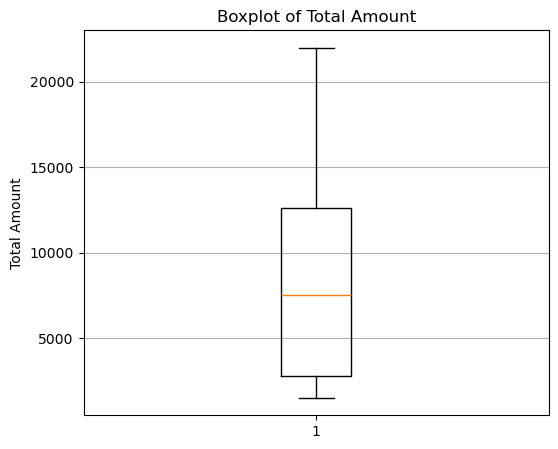

In [367]:
plt.figure(figsize=(6, 5))

plt.boxplot(df["total_amount"])

plt.title("Boxplot of Total Amount")
plt.ylabel("Total Amount")
plt.grid(axis="y")
plt.show()


### Вывод по boxplot

На boxplot по `total_amount` не видно отдельных точек за пределами усов. Это подтверждает результат метода IQR: статистических выбросов в колонке `total_amount` нет.

Клиент Sergey с суммой покупок 22000 является самым ценным клиентом в выборке, но не считается статистическим выбросом по методу IQR.

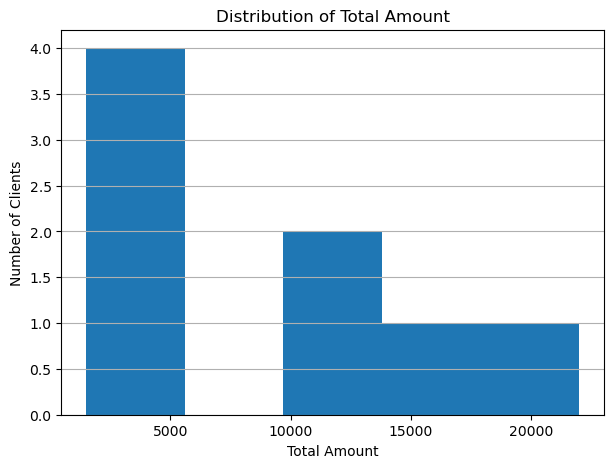

In [368]:
plt.figure(figsize=(7, 5))

plt.hist(df["total_amount"], bins=5)

plt.title("Distribution of Total Amount")
plt.xlabel("Total Amount")
plt.ylabel("Number of Clients")
plt.grid(axis="y")

plt.show()

### Выводы по гистограмме

1. Большая часть клиентов находится в нижнем диапазоне `total_amount`.
2. С увеличением общей суммы покупок количество клиентов уменьшается.
3. Распределение имеет правосторонний перекос: несколько клиентов имеют значительно более высокие суммы покупок, чем основная часть выборки.
4. Также заметен разрыв в данных: в диапазоне примерно от 5000 до 10000 нет клиентов.

## 7. Сравнение городов

In [369]:
df.groupby("town").agg(
  total_amount_count =  ("total_amount", "count"),
  total_amount_mean =   ("total_amount", "mean"),
  total_amount_median = ("total_amount", "median"),
  total_amount_min =    ("total_amount", "min"),
  total_amount_max =    ("total_amount", "max"),
  total_amount_std =    ("total_amount", "std")
)

,total_amount_count,total_amount_mean,total_amount_median,total_amount_min,total_amount_max,total_amount_std
town,,,,,,
Kazan,3,12333.333333,11000.0,4000,22000,9073.771726
Moscow,4,8125.000000,7250.0,2000,16000,6762.334410
Samara,1,1500.000000,1500.0,1500,1500,NaN


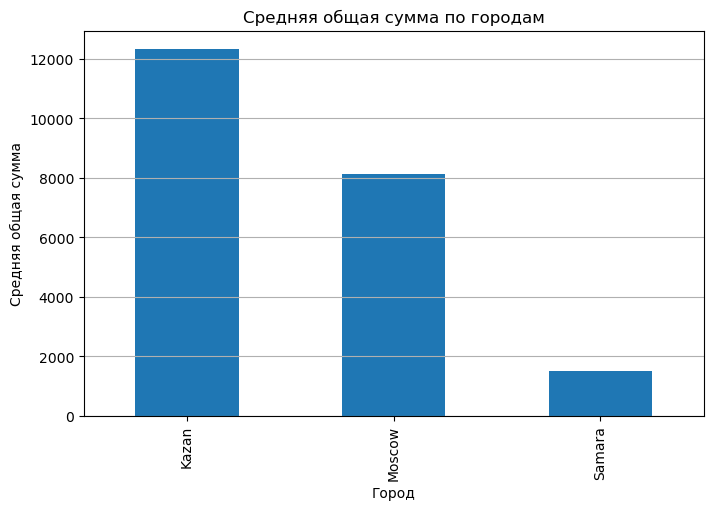

In [370]:
towns_avg_amount = (
  df.groupby("town")["total_amount"]
  .mean()
  .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

towns_avg_amount.plot(kind="bar")

plt.title("Средняя общая сумма по городам")
plt.xlabel("Город")
plt.ylabel("Средняя общая сумма")
plt.grid(axis="y")

plt.show()

### Выводы по столбчатой диаграмме

Казань лидирует по средней и медианной общей сумме. В то же время Москва лидирует по количеству клиентов. По текущей выборке Москва и Казань выглядят наиболее перспективными: Москва — по количеству клиентов, Казань — по общей сумме покупок. Однако из-за маленькой выборки вывод предварительный.

In [371]:
full_total_amount = df["total_amount"].sum()
clients_total = df["client_name"].count()

result = df.groupby("town").agg(
  count_of_clients = ("client_name", "count"),
  town_total_amount = ("total_amount", "sum")
)

result["clients_percentage"] = round(result["count_of_clients"] / clients_total * 100.0, 2)
result["total_amount_percentage"] = round(result["town_total_amount"] / full_total_amount * 100.0, 2)

result

,count_of_clients,town_total_amount,clients_percentage,total_amount_percentage
town,,,,
Kazan,3,37000,37.5,52.11
Moscow,4,32500,50.0,45.77
Samara,1,1500,12.5,2.11


### Выводы:
Больше всего клиентов из Москвы, однако при этом больше половины выручки даёт Казань. По текущей выборке Москва и Казань выглядят перспективнее Самары: Москва — по количеству клиентов, Казань — по доле общей суммы покупок. Однако из-за маленького объёма данных вывод предварительный.

## 8. Проверка гипотезы

Гипотеза: клиенты из Казани в среднем тратят больше, чем клиенты из Москвы.

In [372]:
moscow_clients = df.loc[df["town"] == "Moscow"]
kazan_clients = df.loc[df["town"] == "Kazan"]

def get_town_stats(town_df):
  return {
    "count_of_clients": town_df["client_name"].count(),
    "avg_total_amount": town_df["total_amount"].mean(),
    "median_total_amount": town_df["total_amount"].median(),
    "min_total_amount": town_df["total_amount"].min(),
    "max_total_amount": town_df["total_amount"].max()
  }

In [373]:
get_town_stats(moscow_clients)

{'count_of_clients': np.int64(4),
 'avg_total_amount': np.float64(8125.0),
 'median_total_amount': 7250.0,
 'min_total_amount': 2000,
 'max_total_amount': 16000}

In [374]:
get_town_stats(kazan_clients)

{'count_of_clients': np.int64(3),
 'avg_total_amount': np.float64(12333.333333333334),
 'median_total_amount': 11000.0,
 'min_total_amount': 4000,
 'max_total_amount': 22000}

### Выводы:
Средняя общая сумма в Казани, однако однозначного вывода сделать нельзя, т.к. результат может быть завышен из-за одного-двух клиентов с большой общей суммой. Медиана общей суммы также выше в Казани, это более реальный показатель для выявления "среднего" клиента. По данной выборке Казань выглядит лучше, но данных недостаточно для твёрдых выводов.

## Финальные выводы
1. Самые ценные клиенты — Sergey и Maria.
2. Среднее `total_amount` выше медианы, значит распределение смещено вправо из-за крупных клиентов.
3. Самая сильная корреляция наблюдается между `orders_count` и `total_amount`.
4. По методу IQR статистических выбросов по `total_amount` не найдено.
5. Москва лидирует по количеству клиентов.
6. Казань даёт наибольшую долю общей суммы покупок.
7. Гипотеза о том, что клиенты из Казани в среднем тратят больше, чем клиенты из Москвы, по текущей выборке выглядит подтверждённой, но данных слишком мало для твёрдого вывода.